In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

In [78]:
def dominates(a: np.ndarray, b: np.ndarray) -> bool:
    return np.all(a >= b) and np.any(a > b)

def get_pareto_indices(mean_rewards: np.ndarray) -> np.ndarray:
    """Indices of non-dominated arms."""
    K = len(mean_rewards)
    is_pareto = np.ones(K, dtype=bool)
    for i in range(K):
        for j in range(K):
            if i != j and dominates(mean_rewards[j], mean_rewards[i]):
                is_pareto[i] = False
                break
    return np.where(is_pareto)[0]

def length_scalarization(reward_vec: np.ndarray, w: np.ndarray, z: np.ndarray) -> float:
    x = np.max((reward_vec - z, np.zeros(len(reward_vec))), axis = 0) / w
    return min(x)

def hypervolume_2d(front: np.ndarray, ref: np.ndarray = np.array([0.0, 0.0])) -> float:
    """Exact 2D hypervolume for a non-dominated front (staircase integration)."""
    if len(front) == 0:
        return 0.0
    pts = np.unique(np.array(front), axis=0)
    pts = pts[np.argsort(pts[:, 0])]          # sort ascending by objective 1
    hv = 0.0
    prev_x = ref[0]
    for p in pts:
        hv += (p[0] - prev_x) * (p[1] - ref[1])
        prev_x = p[0]
    return hv

In [80]:
class STR_ScalarizedMultiObjectiveUCB:
    def __init__(self, K: int, D: int, weights_list: list[np.ndarray],
                 z: np.ndarray | None = None, rho: float = 0.01):
        if z is None:
            z = np.full(D, -0.01)
        self.K = K
        self.D = D
        self.z = np.asarray(z)
        self.rho = rho
        self.weights_list = [np.asarray(w) for w in weights_list]
        self.S = len(weights_list)

        # Global vector statistics (updated on every pull)
        self.ni = np.zeros(K, dtype=int)
        self.sum_vec = np.zeros((K, D))
        self.mean_vec = np.zeros((K, D))

        # One UCB instance per scalarization
        self.scalar_ucbs = []
        for w in self.weights_list:
            self.scalar_ucbs.append({
                "nj": 0,
                "nji": np.zeros(K, dtype=int),
                "sum_scalar": np.zeros(K),
                "mean_scalar": np.zeros(K)
            })
        self.n = 0

    def select_action(self) -> tuple[int, int]:
        """Return (arm, scalarizer_index) to pull."""
        j = np.random.randint(self.S)
        sub = self.scalar_ucbs[j]
        if np.any(sub["nji"] == 0):
            arm = int(np.argmin(sub["nji"]))
        else:
            ucb = (sub["mean_scalar"] +
                   np.sqrt(2 * np.log(max(sub["nj"], 1)) / sub["nji"]))
            arm = int(np.argmax(ucb))
        return arm, j

    def update(self, arm: int, j: int, reward_vec: np.ndarray) -> None:
        """Update after a pull."""
        reward_vec = np.asarray(reward_vec)
        scalar_r = length_scalarization(reward_vec, self.weights_list[j], self.z) # self.rho)
        # Update scalarizer-specific UCB
        sub = self.scalar_ucbs[j]
        sub["nji"][arm] += 1
        sub["nj"] += 1
        sub["sum_scalar"][arm] += scalar_r
        sub["mean_scalar"][arm] = sub["sum_scalar"][arm] / sub["nji"][arm] # robustification
        # Update global vector mean
        self.ni[arm] += 1
        self.sum_vec[arm] += reward_vec
        self.mean_vec[arm] = self.sum_vec[arm] / self.ni[arm]
        self.n += 1

In [81]:
class RTS_ScalarizedMultiObjectiveUCB:
    def __init__(self, K: int, D: int, weights_list: list[np.ndarray],
                 z: np.ndarray | None = None, rho: float = 0.01):
        if z is None:
            z = np.full(D, -0.01)
        self.K = K
        self.D = D
        self.z = np.asarray(z)
        self.rho = rho
        self.weights_list = [np.asarray(w) for w in weights_list]
        self.S = len(weights_list)

        # Global vector statistics (updated on every pull)
        self.ni = np.zeros(K, dtype=int)
        self.sum_vec = np.zeros((K, D))
        self.mean_vec = np.zeros((K, D))

        # One UCB instance per scalarization
        self.scalar_ucbs = []
        for w in self.weights_list:
            self.scalar_ucbs.append({
                "nj": 0,
                "nji": np.zeros(K, dtype=int),
                "mean_scalar": np.zeros(K)
            })
        self.n = 0

    def select_action(self) -> tuple[int, int]:
        """Return (arm, scalarizer_index) to pull."""
        j = np.random.randint(self.S)
        sub = self.scalar_ucbs[j]
        if np.any(sub["nji"] == 0):
            arm = int(np.argmin(sub["nji"]))
        else:
            ucb = (sub["mean_scalar"] +
                   np.sqrt(2 * np.log(max(sub["nj"], 1)) / sub["nji"]))
            arm = int(np.argmax(ucb))
        return arm, j

    def update(self, arm: int, j: int, reward_vec: np.ndarray) -> None:
        """Update after a pull."""
        reward_vec = np.asarray(reward_vec)
        # Update scalarizer-specific UCB
        sub = self.scalar_ucbs[j]
        sub["nji"][arm] += 1
        sub["nj"] += 1
        sub["mean_scalar"][arm] = length_scalarization(self.mean_vec[arm], self.weights_list[j], self.z)
        # Update global vector mean
        self.ni[arm] += 1
        self.sum_vec[arm] += reward_vec
        self.mean_vec[arm] = self.sum_vec[arm] / self.ni[arm]
        self.n += 1

In [82]:
class STR_ImprovedScalarizedMultiObjectiveUCB:
    def __init__(self, K: int, D: int, weights_list: list[np.ndarray],
                 T: int, z: np.ndarray | None = None, rho: float = 0.01):
        if z is None:
            z = np.full(D, -0.01)
        self.K = K
        self.D = D
        self.T = T
        self.z = np.asarray(z)
        self.rho = rho
        self.weights_list = [np.asarray(w) for w in weights_list]
        self.S = len(weights_list)

        # Global statistics
        self.ni = np.zeros(K, dtype=int)
        self.sum_vec = np.zeros((K, D))
        self.mean_vec = np.zeros((K, D))

        # Scalarizer-specific UCBs (same as above)
        self.scalar_ucbs = []
        for w in self.weights_list:
            self.scalar_ucbs.append({
                "nj": 0,
                "nji": np.zeros(K, dtype=int),
                "sum_scalar": np.zeros(K),
                "mean_scalar": np.zeros(K)
            })

        self.active = list(range(self.S))          # indices of remaining scalarizers
        self.Delta = 1.0
        self.n = 0

    def _compute_unfairness(self, j: int, pareto_idx: np.ndarray) -> float:
        """Unfairness φ (Eq. 5) for scalarizer j on the current Pareto set."""
        sub = self.scalar_ucbs[j]
        pulls = sub["nji"][pareto_idx]
        if len(pareto_idx) == 0 or pulls.sum() == 0:
            return 0.0
        mean_pulls = pulls.mean()
        phi = np.mean((pulls - mean_pulls) ** 2)
        return float(phi)

    def run(self, bandit_pull_fn) -> dict:
        """
        Run the full algorithm for horizon T.
        bandit_pull_fn(arm) must return a D-dimensional reward vector.
        """
        m_max = int(0.5 * np.log2(self.T / np.e))
        for m in range(m_max + 1):
            if len(self.active) <= 1:
                # Only one scalarizer left → use it until T
                j = self.active[0]
                while self.n < self.T:
                    arm = self._choose_arm_single(j)
                    rew = bandit_pull_fn(arm)
                    self._update_single(j, arm, rew)
                break

            nm = int(np.ceil(2 * np.log(self.T / self.Delta**2) / self.Delta**2))
            nm = min(nm, self.T - self.n)

            # Run each active scalarizer for nm steps
            for j in self.active:
                for _ in range(nm):
                    if self.n >= self.T:
                        break
                    arm = self._choose_arm_single(j)
                    rew = bandit_pull_fn(arm)
                    self._update_single(j, arm, rew)

            # Re-estimate Pareto set from global means
            pareto_idx = get_pareto_indices(self.mean_vec)

            # Elimination step
            phis = [self._compute_unfairness(j, pareto_idx) for j in self.active]
            conf = np.sqrt(np.log(self.T / self.Delta**2) / (2 * nm))
            min_phi = min(phis)
            to_keep = []
            for idx, j in enumerate(self.active):
                if phis[idx] - conf <= min_phi + conf:
                    to_keep.append(j)
            self.active = to_keep

            self.Delta /= 2.0

        return {
            "final_mean_vec": self.mean_vec.copy(),
            "pulls": self.ni.copy(),
            "pareto_indices": get_pareto_indices(self.mean_vec)
        }

    def _choose_arm_single(self, j: int) -> int:
        sub = self.scalar_ucbs[j]
        if np.any(sub["nji"] == 0):
            return int(np.argmin(sub["nji"]))
        ucb = sub["mean_scalar"] + np.sqrt(2 * np.log(max(sub["nj"], 1)) / sub["nji"])
        return int(np.argmax(ucb))

    def _update_single(self, j: int, arm: int, reward_vec: np.ndarray) -> None:
        scalar_r = length_scalarization(reward_vec, self.weights_list[j], self.z)
        sub = self.scalar_ucbs[j]
        sub["nji"][arm] += 1
        sub["nj"] += 1
        sub["sum_scalar"][arm] += scalar_r
        sub["mean_scalar"][arm] = sub["sum_scalar"][arm] / sub["nji"][arm]

        # Global update
        self.ni[arm] += 1
        self.sum_vec[arm] += reward_vec
        self.mean_vec[arm] = self.sum_vec[arm] / self.ni[arm]
        self.n += 1

In [83]:
class RTS_ImprovedScalarizedMultiObjectiveUCB:
    def __init__(self, K: int, D: int, weights_list: list[np.ndarray],
                 T: int, z: np.ndarray | None = None, rho: float = 0.01):
        if z is None:
            z = np.full(D, -0.01)
        self.K = K
        self.D = D
        self.T = T
        self.z = np.asarray(z)
        self.rho = rho
        self.weights_list = [np.asarray(w) for w in weights_list]
        self.S = len(weights_list)

        # Global statistics
        self.ni = np.zeros(K, dtype=int)
        self.sum_vec = np.zeros((K, D))
        self.mean_vec = np.zeros((K, D))

        # Scalarizer-specific UCBs (same as above)
        self.scalar_ucbs = []
        for w in self.weights_list:
            self.scalar_ucbs.append({
                "nj": 0,
                "nji": np.zeros(K, dtype=int),
                "mean_scalar": np.zeros(K)
            })

        self.active = list(range(self.S))          # indices of remaining scalarizers
        self.Delta = 1.0
        self.n = 0

    def _compute_unfairness(self, j: int, pareto_idx: np.ndarray) -> float:
        """Unfairness φ (Eq. 5) for scalarizer j on the current Pareto set."""
        sub = self.scalar_ucbs[j]
        pulls = sub["nji"][pareto_idx]
        if len(pareto_idx) == 0 or pulls.sum() == 0:
            return 0.0
        mean_pulls = pulls.mean()
        phi = np.mean((pulls - mean_pulls) ** 2)
        return float(phi)

    def run(self, bandit_pull_fn) -> dict:
        """
        Run the full algorithm for horizon T.
        bandit_pull_fn(arm) must return a D-dimensional reward vector.
        """
        m_max = int(0.5 * np.log2(self.T / np.e))
        for m in range(m_max + 1):
            if len(self.active) <= 1:
                # Only one scalarizer left → use it until T
                j = self.active[0]
                while self.n < self.T:
                    arm = self._choose_arm_single(j)
                    rew = bandit_pull_fn(arm)
                    self._update_single(j, arm, rew)
                break

            nm = int(np.ceil(2 * np.log(self.T / self.Delta**2) / self.Delta**2))
            nm = min(nm, self.T - self.n)

            # Run each active scalarizer for nm steps
            for j in self.active:
                for _ in range(nm):
                    if self.n >= self.T:
                        break
                    arm = self._choose_arm_single(j)
                    rew = bandit_pull_fn(arm)
                    self._update_single(j, arm, rew)

            # Re-estimate Pareto set from global means
            pareto_idx = get_pareto_indices(self.mean_vec)

            # Elimination step
            phis = [self._compute_unfairness(j, pareto_idx) for j in self.active]
            conf = np.sqrt(np.log(self.T / self.Delta**2) / (2 * nm))
            min_phi = min(phis)
            to_keep = []
            for idx, j in enumerate(self.active):
                if phis[idx] - conf <= min_phi + conf:
                    to_keep.append(j)
            self.active = to_keep

            self.Delta /= 2.0

        return {
            "final_mean_vec": self.mean_vec.copy(),
            "pulls": self.ni.copy(),
            "pareto_indices": get_pareto_indices(self.mean_vec)
        }

    def _choose_arm_single(self, j: int) -> int:
        sub = self.scalar_ucbs[j]
        if np.any(sub["nji"] == 0):
            return int(np.argmin(sub["nji"]))
        ucb = sub["mean_scalar"] + np.sqrt(2 * np.log(max(sub["nj"], 1)) / sub["nji"])
        return int(np.argmax(ucb))

    def _update_single(self, j: int, arm: int, reward_vec: np.ndarray) -> None:
        sub = self.scalar_ucbs[j]
        sub["nji"][arm] += 1
        sub["nj"] += 1
        sub["mean_scalar"][arm] = length_scalarization(self.mean_vec[arm], self.weights_list[j], self.z)

        # Global update
        self.ni[arm] += 1
        self.sum_vec[arm] += reward_vec
        self.mean_vec[arm] = self.sum_vec[arm] / self.ni[arm]
        self.n += 1

In [104]:
class EmpiricalParetoUCB:
    def __init__(self, K: int, D: int):
        self.K = K
        self.D = D
        self.ni = np.zeros(K, dtype=int)
        self.sum_vec = np.zeros((K, D))
        self.mean_vec = np.zeros((K, D))
        self.n = 0
        self.hypervolume_history = []

    def _compute_ucb_vectors(self) -> np.ndarray:
        """UCB vector = mean + standard UCB confidence (problem-independent)."""
        # Avoid division by zero for unpulled arms (handled by init)
        c = np.sqrt(2 * np.log(max(self.n, 1)) / np.maximum(self.ni, 1))
        ucb = self.mean_vec + c[:, np.newaxis]   # broadcast scalar confidence to all objectives
        return ucb

    def run(self, bandit_pull_fn, T: int, monitor_hv: bool = True) -> dict:
        """
        Run for horizon T.
        bandit_pull_fn(arm) must return a D-dimensional reward vector.
        """
        # ------------------- Initialization: play each arm once -------------------
        for arm in range(self.K):
            rew = bandit_pull_fn(arm)
            self.ni[arm] += 1
            self.sum_vec[arm] += rew
            self.mean_vec[arm] = self.sum_vec[arm] / self.ni[arm]
        self.n = self.K

        # ------------------- Main loop with optional hypervolume monitoring -------------------
        step = self.n
        while step < T:
            ucb = self._compute_ucb_vectors()
            pareto_idx = get_pareto_indices(ucb)          # current non-dominated UCB vectors
            arm = np.random.choice(pareto_idx)            # uniform selection from current Pareto set

            rew = bandit_pull_fn(arm)

            # Update statistics
            self.ni[arm] += 1
            self.sum_vec[arm] += rew
            self.mean_vec[arm] = self.sum_vec[arm] / self.ni[arm]
            self.n += 1
            step += 1

            current_pareto_idx = get_pareto_indices(self.mean_vec)
            current_front = self.mean_vec[current_pareto_idx]
            hv = hypervolume_2d(current_front)
            self.hypervolume_history.append(hv)

        return self.hypervolume_history.copy()

In [6]:
class MultiObjectiveBernoulliBandit:
    def __init__(self, means):
        self.means = np.array(means)          # shape (K, D)
        self.K = len(means)
        self.D = self.means.shape[1]
    
    def pull(self, arm):
        """Return a D-dimensional Bernoulli reward vector."""
        return np.random.binomial(1, self.means[arm]).astype(float)

# Reward means (4 optimal arms from Example 1 + 6 suboptimal arms)
means = [
    [0.55, 0.50],   # μ1*
    [0.53, 0.51],   # μ2*
    [0.52, 0.54],   # μ3*
    [0.50, 0.57],   # μ4*
    [0.48, 0.48],
    [0.49, 0.47],
    [0.47, 0.49],
    [0.46, 0.46],
    [0.51, 0.45],
    [0.45, 0.52]
]
means += [list(np.random.uniform(0, .1, 2)) for i in range(10)]

bandit = MultiObjectiveBernoulliBandit(means)
optimal_arms = [0, 1, 2, 3]   # indices of the true Pareto-optimal arms

In [7]:
b = MultiObjectiveBernoulliBandit(means)

In [35]:
b.pull(0)

array([1., 0.])

In [85]:
# ====================== Weight vectors for augmented Chebyshev ======================
weights_list = [np.array([w1, 1.0 - w1]) for w1 in np.linspace(0.01, 0.09, 100)]

In [86]:
RTS_ucb_basic = RTS_ScalarizedMultiObjectiveUCB(K=bandit.K, D=bandit.D, weights_list=weights_list)

RTS_hv_history = []

for t in range(100):
    arm, j = RTS_ucb_basic.select_action()
    reward_vec = bandit.pull(arm)
    RTS_ucb_basic.update(arm, j, reward_vec)
    
    pareto_idx = get_pareto_indices(RTS_ucb_basic.mean_vec)
    current_front = RTS_ucb_basic.mean_vec[pareto_idx]
    hv = hypervolume_2d(current_front)
    RTS_hv_history.append(hv)

get_pareto_indices(RTS_ucb_basic.mean_vec)

array([1, 2])

In [87]:
STR_ucb_basic = STR_ScalarizedMultiObjectiveUCB(K=bandit.K, D=bandit.D, weights_list=weights_list)

STR_hv_history = []

for t in range(100):
    arm, j = STR_ucb_basic.select_action()
    reward_vec = bandit.pull(arm)
    STR_ucb_basic.update(arm, j, reward_vec)
    
    pareto_idx = get_pareto_indices(STR_ucb_basic.mean_vec)
    current_front = STR_ucb_basic.mean_vec[pareto_idx]
    hv = hypervolume_2d(current_front)
    STR_hv_history.append(hv)

get_pareto_indices(STR_ucb_basic.mean_vec)

array([1, 2, 3])

In [88]:
STR_improved_ucb = STR_ImprovedScalarizedMultiObjectiveUCB(K=bandit.K, D=bandit.D,
                                                   weights_list=weights_list, T=100)
step_counter = [0]

STR_improved_hv_history = []

def monitored_pull(arm: int):
    global RTS_improved_hv_history
    rew = bandit.pull(arm)
    step_counter[0] += 1
    pareto_idx = get_pareto_indices(STR_improved_ucb.mean_vec)
    current_front = STR_improved_ucb.mean_vec[pareto_idx]
    hv = hypervolume_2d(current_front)
    RTS_improved_hv_history.append(hv)
    return rew

res = STR_improved_ucb.run(monitored_pull)

/tmp/ipykernel_37060/306445266.py:76: RuntimeWarning: divide by zero encountered in scalar divide
  conf = np.sqrt(np.log(self.T / self.Delta**2) / (2 * nm))


In [89]:
RTS_improved_ucb = RTS_ImprovedScalarizedMultiObjectiveUCB(K=bandit.K, D=bandit.D,
                                                   weights_list=weights_list, T=100)
step_counter = [0]

RTS_improved_hv_history = []

def monitored_pull(arm: int):
    global RTS_improved_hv_history
    rew = bandit.pull(arm)
    step_counter[0] += 1
    pareto_idx = get_pareto_indices(RTS_improved_ucb.mean_vec)
    current_front = RTS_improved_ucb.mean_vec[pareto_idx]
    hv = hypervolume_2d(current_front)
    RTS_improved_hv_history.append(hv)
    return rew

res = RTS_improved_ucb.run(monitored_pull)

/tmp/ipykernel_37060/1026667513.py:75: RuntimeWarning: divide by zero encountered in scalar divide
  conf = np.sqrt(np.log(self.T / self.Delta**2) / (2 * nm))


In [105]:
RTS_hypervolumes = []
STR_hypervolumes = []
RTS_improved_hypervolumes = []
STR_improved_hypervolumes = []
Pareto_UCB_hypervolume = []

T = 200

for trial in trange(100):
    RTS_ucb_basic = RTS_ScalarizedMultiObjectiveUCB(K=bandit.K, D=bandit.D, weights_list=weights_list)
    RTS_hv_history = []
    for t in range(T):
        arm, j = RTS_ucb_basic.select_action()
        reward_vec = bandit.pull(arm)
        RTS_ucb_basic.update(arm, j, reward_vec)
    
        pareto_idx = get_pareto_indices(RTS_ucb_basic.mean_vec)
        current_front = RTS_ucb_basic.mean_vec[pareto_idx]
        hv = hypervolume_2d(current_front)
        RTS_hv_history.append(hv)
    RTS_hypervolumes.append(RTS_hv_history)

    STR_ucb_basic = RTS_ScalarizedMultiObjectiveUCB(K=bandit.K, D=bandit.D, weights_list=weights_list)
    STR_hv_history = []
    for t in range(T):
        arm, j = STR_ucb_basic.select_action()
        reward_vec = bandit.pull(arm)
        STR_ucb_basic.update(arm, j, reward_vec)
    
        pareto_idx = get_pareto_indices(STR_ucb_basic.mean_vec)
        current_front = STR_ucb_basic.mean_vec[pareto_idx]
        hv = hypervolume_2d(current_front)
        STR_hv_history.append(hv)
    STR_hypervolumes.append(STR_hv_history)

    STR_improved_ucb = RTS_ImprovedScalarizedMultiObjectiveUCB(K=bandit.K, D=bandit.D,
                                                   weights_list=weights_list, T=T)
    step_counter = [0]
    STR_improved_hv_history = []
    def monitored_pull(arm: int):
        global STR_improved_hv_history
        rew = bandit.pull(arm)
        step_counter[0] += 1
        pareto_idx = get_pareto_indices(STR_improved_ucb.mean_vec)
        current_front = STR_improved_ucb.mean_vec[pareto_idx]
        hv = hypervolume_2d(current_front)
        STR_improved_hv_history.append(hv)
        return rew
    res = STR_improved_ucb.run(monitored_pull)
    STR_improved_hypervolumes.append(STR_improved_hv_history)

    RTS_improved_ucb = RTS_ImprovedScalarizedMultiObjectiveUCB(K=bandit.K, D=bandit.D,
                                                   weights_list=weights_list, T=T)
    step_counter = [0]
    RTS_improved_hv_history = []
    def monitored_pull(arm: int):
        global RTS_improved_hv_history
        rew = bandit.pull(arm)
        step_counter[0] += 1
        pareto_idx = get_pareto_indices(RTS_improved_ucb.mean_vec)
        current_front = RTS_improved_ucb.mean_vec[pareto_idx]
        hv = hypervolume_2d(current_front)
        RTS_improved_hv_history.append(hv)
        return rew
    res = RTS_improved_ucb.run(monitored_pull)
    RTS_improved_hypervolumes.append(RTS_improved_hv_history)

    pareto_ucb = EmpiricalParetoUCB(K=bandit.K, D=bandit.D)
    result_pareto = pareto_ucb.run(bandit.pull, T=T)

    Pareto_UCB_hypervolume.append(result_pareto)

  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_37060/1026667513.py:75: RuntimeWarning: divide by zero encountered in scalar divide
  conf = np.sqrt(np.log(self.T / self.Delta**2) / (2 * nm))
100%|██████████| 100/100 [00:42<00:00,  2.33it/s]


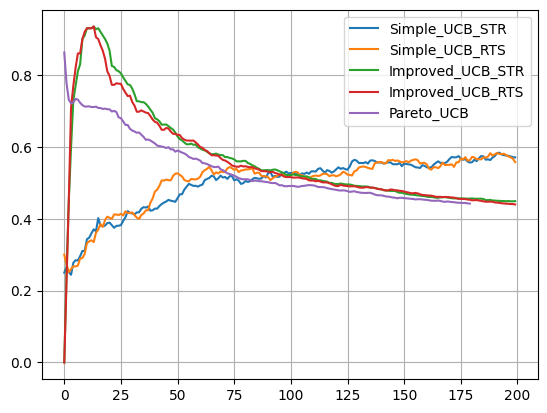

In [114]:
plt.plot(np.array(STR_hypervolumes).mean(axis=0), label = 'Simple_UCB_STR')
plt.plot(np.array(RTS_hypervolumes).mean(axis=0), label = 'Simple_UCB_RTS')
plt.plot(np.array(STR_improved_hypervolumes).mean(axis=0), label = 'Improved_UCB_STR')
plt.plot(np.array(RTS_improved_hypervolumes).mean(axis=0), label = 'Improved_UCB_RTS')
plt.plot(np.array(Pareto_UCB_hypervolume).mean(axis=0), label = 'Pareto_UCB')
plt.grid()
plt.legend()